# Modeling on Diabetes Prediction Dataset

In [1]:
# Import from files
from data_processing import preprocess_data, inverse_transform
from modeling import create_models, run_experiments, evaluate_model

## Prepare data for training

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(
    undersample=False,
    scaler=scaler
)

Our dataset source: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

Cleaned Dataset:
    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
5  20.0             0              0  27.32          6.6                   85   
6  44.0             0              0  19.31          6.5                  200   

   diabetes  gender_Female  gender_Male  gender_Other  \
0         0              1            0             0   
1         0              1            0             0   
2         0              0            1             0   
5         0              1            0             0   
6         1              1            0             0   

   smoking_history_No Info  smoking_history_current  smokin

## Run Experiments

In [3]:
models = create_models()
models

{'baseline': DummyClassifier(),
 'lr_model': LogisticRegressionCV(random_state=1234),
 'knn_model': KNeighborsClassifier(),
 'dt_model': DecisionTreeClassifier(random_state=1234),
 'random_forest_model': RandomForestClassifier(random_state=1234),
 'adaboost_model': AdaBoostClassifier(random_state=1234),
 'gradient_boosting_model': GradientBoostingClassifier(random_state=1234),
 'voting_hard_model': VotingClassifier(estimators=[('lr_model',
                               LogisticRegressionCV(random_state=1234)),
                              ('knn_model', KNeighborsClassifier()),
                              ('dt_model',
                               DecisionTreeClassifier(random_state=1234)),
                              ('random_forest_model',
                               RandomForestClassifier(random_state=1234)),
                              ('adaboost_model',
                               AdaBoostClassifier(random_state=1234)),
                              ('gradient_boosti

In [4]:
reports = run_experiments(models, X_train, y_train, X_val, y_val)



Fitting baseline...
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     10762
           1       0.00      0.00      0.00      1666

    accuracy                           0.87     12428
   macro avg       0.43      0.50      0.46     12428
weighted avg       0.75      0.87      0.80     12428



Fitting lr_model...


/home/studio-lab-user/.conda/envs/default/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/studio-lab-user/.conda/envs/default/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/studio-lab-user/.conda/envs/default/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     10762
           1       0.89      0.60      0.71      1666

    accuracy                           0.94     12428
   macro avg       0.92      0.79      0.84     12428
weighted avg       0.93      0.94      0.93     12428



Fitting knn_model...
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10762
           1       0.91      0.64      0.75      1666

    accuracy                           0.94     12428
   macro avg       0.93      0.81      0.86     12428
weighted avg       0.94      0.94      0.94     12428



Fitting dt_model...
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10762
           1       0.71      0.74      0.72      1666

    accuracy                           0.92     12428
   macro avg       0.83      0.85      0.84     12428
weighted avg       0.93      

## Model Evaluation

### Voting Ensemble

In [5]:
models['voting_hard_model'].get_params()

{'estimators': [('lr_model', LogisticRegressionCV(random_state=1234)),
  ('knn_model', KNeighborsClassifier()),
  ('dt_model', DecisionTreeClassifier(random_state=1234)),
  ('random_forest_model', RandomForestClassifier(random_state=1234)),
  ('adaboost_model', AdaBoostClassifier(random_state=1234)),
  ('gradient_boosting_model', GradientBoostingClassifier(random_state=1234))],
 'flatten_transform': True,
 'n_jobs': None,
 'verbose': False,
 'voting': 'hard',
 'weights': None,
 'lr_model': LogisticRegressionCV(random_state=1234),
 'knn_model': KNeighborsClassifier(),
 'dt_model': DecisionTreeClassifier(random_state=1234),
 'random_forest_model': RandomForestClassifier(random_state=1234),
 'adaboost_model': AdaBoostClassifier(random_state=1234),
 'gradient_boosting_model': GradientBoostingClassifier(random_state=1234),
 'lr_model__Cs': 10,
 'lr_model__class_weight': None,
 'lr_model__cv': None,
 'lr_model__dual': False,
 'lr_model__fit_intercept': True,
 'lr_model__intercept_scaling': 1

### Random Forest Model

Text(0, 0.5, 'Feature Importance Score')

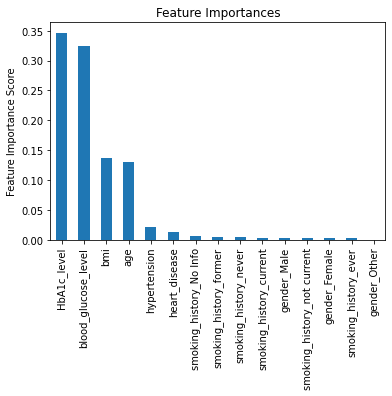

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(models["random_forest_model"].feature_importances_, X_train.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importances')
plt.ylabel('Feature Importance Score')

### Gradient Boosting Model (Best So Far)

Text(0, 0.5, 'Feature Importance Score')

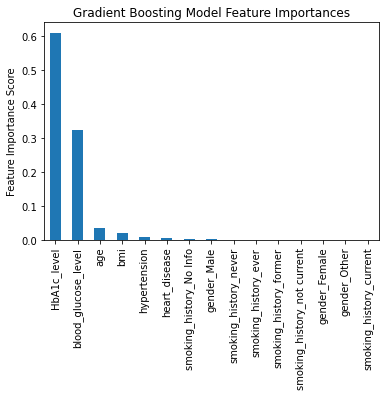

In [7]:
feat_imp = pd.Series(models["gradient_boosting_model"].feature_importances_, X_train.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Gradient Boosting Model Feature Importances')
plt.ylabel('Feature Importance Score')

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     32161
           1       0.99      0.69      0.81      5124

    accuracy                           0.96     37285
   macro avg       0.97      0.84      0.89     37285
weighted avg       0.96      0.96      0.95     37285

Failed prediction count: 1647


/home/studio-lab-user/sagemaker-studiolab-notebooks/w207_final_project_meng_sherman/data_processing.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[scale_columns] = scaler.inverse_transform(data[scale_columns])


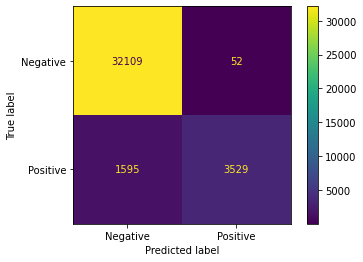

In [8]:
failed_df = evaluate_model(models["gradient_boosting_model"], X_train, y_train)

unscaled_df = inverse_transform(scaler, failed_df)

print(f"Failed prediction count: {len(unscaled_df)}")

#### Histograms of distribution of failed prediction observations

(array([  4.,  17.,  12.,  58.,  90., 164., 275., 299., 301., 427.]),
 array([ 4. , 11.6, 19.2, 26.8, 34.4, 42. , 49.6, 57.2, 64.8, 72.4, 80. ]),
 <BarContainer object of 10 artists>)

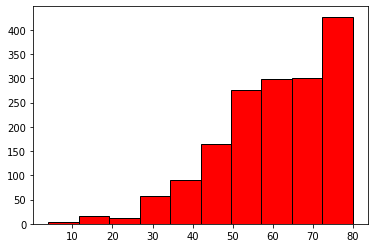

In [9]:
plt.hist(unscaled_df["age"], bins=10, edgecolor='black', color='red')


(array([  8., 139., 682., 422., 225., 108.,  42.,  15.,   4.,   2.]),
 array([12.91 , 18.558, 24.206, 29.854, 35.502, 41.15 , 46.798, 52.446,
        58.094, 63.742, 69.39 ]),
 <BarContainer object of 10 artists>)

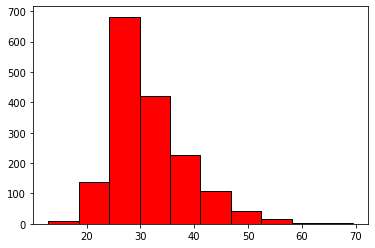

In [10]:
plt.hist(unscaled_df["bmi"], bins=10, edgecolor='black', color='red')


(array([406., 183., 224., 183., 451.,   0.,   0.,   0.,   0., 200.]),
 array([126. , 133.4, 140.8, 148.2, 155.6, 163. , 170.4, 177.8, 185.2,
        192.6, 200. ]),
 <BarContainer object of 10 artists>)

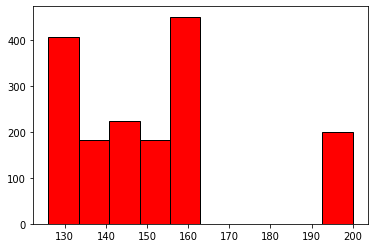

In [11]:
plt.hist(unscaled_df["blood_glucose_level"], bins=10, edgecolor='black', color='red')


(array([249., 226.,   0., 232., 220., 237.,   0.,   0., 227., 256.]),
 array([5.7 , 5.79, 5.88, 5.97, 6.06, 6.15, 6.24, 6.33, 6.42, 6.51, 6.6 ]),
 <BarContainer object of 10 artists>)

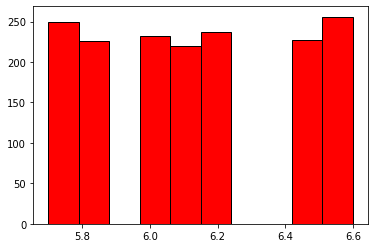

In [12]:

plt.hist(unscaled_df["HbA1c_level"], bins=10, edgecolor='black', color='red')


In [13]:
# Diabetes label with lower A1c

df = X_train[X_train["HbA1c_level"] < 6.7]
df[y_train == 1]

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
5737,0.312717,1,0,0.699180,-0.249005,3.616183,0,1,0,0,1,0,0,0,0
87401,0.091355,0,0,-0.629360,4.531098,-0.028125,1,0,0,0,0,0,0,1,0
1549,0.666895,0,0,0.663791,1.344363,1.794029,1,0,0,0,0,0,0,1,0
20006,0.932529,0,0,-0.036604,3.468853,0.313529,0,1,0,0,0,0,0,0,1
45194,0.179900,0,0,0.245029,4.885180,-0.028125,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33271,0.799712,1,0,1.076656,-0.249005,1.338490,0,1,0,0,0,0,1,0,0
29767,0.356989,0,0,1.968739,2.229567,1.794029,0,1,0,0,1,0,0,0,0
87225,1.508070,0,0,-0.338880,-0.426046,0.313529,1,0,0,0,0,0,1,0,0
82779,1.596614,1,1,0.781753,-0.249005,-0.028125,0,1,0,0,0,0,1,0,0
